In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar gráficos bonitos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Bibliotecas carregadas!")

# Carregar os 3 arquivos (ajuste o caminho se precisar)
df_orders = pd.read_csv('../data/raw_orders.csv')
df_customers = pd.read_csv('../data/raw_customers.csv')
df_marketing = pd.read_csv('../data/raw_marketing_spend.csv')

# Ver o que tem em cada um (isso ajuda a entender os dados)
print("Colunas dos Pedidos:", df_orders.columns.tolist())
print("Colunas dos Clientes:", df_customers.columns.tolist())
print("Colunas do Marketing:", df_marketing.columns.tolist())

Bibliotecas carregadas!
Colunas dos Pedidos: ['order_id', 'order_date', 'amount', 'status', 'customer_id', 'items_quantity', 'product_category', 'discount_amount', 'coupon_code', 'device_type', 'utm_source', 'utm_medium', 'utm_campaign', 'estimated_delivery_days']
Colunas dos Clientes: ['customer_id', 'customer_name', 'email', 'created_at', 'state_code', 'acquisition_channel', 'income_bracket', 'birth_date', 'engagement_score']
Colunas do Marketing: ['spend_date', 'channel', 'campaign_name', 'daily_investment', 'impressions', 'clicks', 'landing_page_views']


## Limpando

In [3]:
# CÉLULA 2 - CONVERSÃO DE DATAS (primeiro ISO, depois BR)

# 1. Limpeza de espaços
df_orders['order_date'] = df_orders['order_date'].astype(str).str.strip()
df_customers['created_at'] = df_customers['created_at'].astype(str).str.strip()
df_marketing['spend_date'] = df_marketing['spend_date'].astype(str).str.strip()

# 2. Primeira tentativa: formato ISO (sem dayfirst)
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'], errors='coerce', dayfirst=False)
df_customers['created_at'] = pd.to_datetime(df_customers['created_at'], errors='coerce', dayfirst=False)
df_marketing['spend_date'] = pd.to_datetime(df_marketing['spend_date'], errors='coerce', dayfirst=False)

# 3. Para os que falharam (NaT), tentar com dayfirst=True (formato BR)
mask_orders = df_orders['order_date'].isna()
if mask_orders.sum() > 0:
    df_orders.loc[mask_orders, 'order_date'] = pd.to_datetime(
        df_orders.loc[mask_orders, 'order_date'].astype(str), 
        errors='coerce', 
        dayfirst=True
    )

mask_cust = df_customers['created_at'].isna()
if mask_cust.sum() > 0:
    df_customers.loc[mask_cust, 'created_at'] = pd.to_datetime(
        df_customers.loc[mask_cust, 'created_at'].astype(str), 
        errors='coerce', 
        dayfirst=True
    )

mask_mark = df_marketing['spend_date'].isna()
if mask_mark.sum() > 0:
    df_marketing.loc[mask_mark, 'spend_date'] = pd.to_datetime(
        df_marketing.loc[mask_mark, 'spend_date'].astype(str), 
        errors='coerce', 
        dayfirst=True
    )

# 4. Remover pedidos com data ainda inválida (se houver)
df_orders = df_orders.dropna(subset=['order_date'])

# 5. Verificar resultado final
print(f"Datas inválidas em Orders (após remoção): {df_orders['order_date'].isna().sum()}")
print(f"Datas inválidas em Customers: {df_customers['created_at'].isna().sum()}")
print(f"Datas inválidas em Marketing: {df_marketing['spend_date'].isna().sum()}")
print(f"Total de pedidos após remoção: {len(df_orders)}")

# 6. Limpeza dos valores numéricos (igual antes)
df_orders['amount'] = df_orders['amount'].astype(str).str.replace('R$', '', regex=False)
df_orders['amount'] = df_orders['amount'].str.replace('$', '', regex=False)
df_orders['amount'] = df_orders['amount'].str.replace(',', '', regex=False)
df_orders['amount'] = df_orders['amount'].str.strip()
df_orders['amount'] = pd.to_numeric(df_orders['amount'], errors='coerce')

df_orders['discount_amount'] = df_orders['discount_amount'].astype(str).str.replace('R$', '', regex=False)
df_orders['discount_amount'] = df_orders['discount_amount'].str.replace('$', '', regex=False)
df_orders['discount_amount'] = df_orders['discount_amount'].str.replace(',', '', regex=False)
df_orders['discount_amount'] = df_orders['discount_amount'].str.strip()
df_orders['discount_amount'] = pd.to_numeric(df_orders['discount_amount'], errors='coerce')

df_marketing['daily_investment'] = df_marketing['daily_investment'].astype(str).str.replace('R$', '', regex=False)
df_marketing['daily_investment'] = df_marketing['daily_investment'].str.replace('$', '', regex=False)
df_marketing['daily_investment'] = df_marketing['daily_investment'].str.replace(',', '', regex=False)
df_marketing['daily_investment'] = df_marketing['daily_investment'].str.strip()
df_marketing['daily_investment'] = pd.to_numeric(df_marketing['daily_investment'], errors='coerce')

# Preencher nulos com 0
df_orders['amount'] = df_orders['amount'].fillna(0)
df_orders['discount_amount'] = df_orders['discount_amount'].fillna(0)
df_marketing['daily_investment'] = df_marketing['daily_investment'].fillna(0)

print(f"\nTipo da coluna 'amount': {df_orders['amount'].dtype}")
print(f"Primeiros valores de 'amount': {df_orders['amount'].head().tolist()}")

# 7. REGRA DE NEGÓCIO: Receita Líquida
df_orders['net_revenue'] = df_orders.apply(
    lambda row: 0 if row['status'] in ['cancelled', 'returned'] else row['amount'],
    axis=1
)
df_orders['is_cancelled'] = df_orders['status'].isin(['cancelled', 'returned'])

print("\n--- RESULTADO DA REGRA DE RECEITA ---")
print(f"Receita Bruta Total: R$ {df_orders['amount'].sum():,.2f}")
print(f"Receita Líquida Total: R$ {df_orders['net_revenue'].sum():,.2f}")
print(f"Percentual de pedidos cancelados/devolvidos: {round(df_orders['is_cancelled'].mean() * 100, 2)}%")

/tmp/ipykernel_82080/682314127.py:9: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_orders['order_date'] = pd.to_datetime(df_orders['order_date'], errors='coerce', dayfirst=False)


Datas inválidas em Orders (após remoção): 0
Datas inválidas em Customers: 0
Datas inválidas em Marketing: 0
Total de pedidos após remoção: 99751

Tipo da coluna 'amount': float64
Primeiros valores de 'amount': [98739.0, 1106.46, 183284.0, 1729.67, 75157.0]

--- RESULTADO DA REGRA DE RECEITA ---
Receita Bruta Total: R$ 4,642,363,026.93
Receita Líquida Total: R$ 3,095,475,346.98
Percentual de pedidos cancelados/devolvidos: 33.23%


In [4]:
# JUNTAR TABELAS

# 1. Juntar Pedidos com Clientes
df_merged = pd.merge(df_orders, df_customers, on='customer_id', how='left')

# 2. Agregar gasto de marketing por dia
df_marketing_daily = df_marketing.groupby('spend_date')['daily_investment'].sum().reset_index()

# 3. Juntar com marketing (cada pedido recebe o gasto do seu dia)
df_merged = pd.merge(df_merged, df_marketing_daily, left_on='order_date', right_on='spend_date', how='left')
df_merged['daily_investment'].fillna(0, inplace=True)  # dias sem gasto viram 0

# 4. Atribuição SIMPLES: canal com maior gasto no dia do pedido
# Para cada dia, pegamos o canal que mais gastou
df_top_channel = df_marketing.loc[df_marketing.groupby('spend_date')['daily_investment'].idxmax()]
df_top_channel = df_top_channel[['spend_date', 'channel']].rename(columns={'channel': 'attributed_channel'})

# Juntar com a tabela principal
df_final = pd.merge(df_merged, df_top_channel, left_on='order_date', right_on='spend_date', how='left')
df_final['attributed_channel'].fillna('Organic', inplace=True)  # dias sem gasto viram 'Organic'

# Remover colunas duplicadas
df_final.drop(columns=['spend_date_x', 'spend_date_y'], inplace=True, errors='ignore')

print(f"\nTabela final criada com {len(df_final)} pedidos.")
print("\nPrimeiras linhas:")
print(df_final[['order_id', 'customer_id', 'amount', 'net_revenue', 'attributed_channel']].head())


Tabela final criada com 99751 pedidos.

Primeiras linhas:
   order_id customer_id     amount  net_revenue attributed_channel
0   1000000      C3078    98739.00     98739.00             FB Ads
1   1000002      C3615     1106.46      1106.46    Email Marketing
2   1000003      C3643   183284.00         0.00         google ads
3   1000004       C822     1729.67         0.00              G Ads
4   1000005      C1640    75157.00         0.00         Google Ads


/tmp/ipykernel_82080/966723321.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['daily_investment'].fillna(0, inplace=True)  # dias sem gasto viram 0
/tmp/ipykernel_82080/966723321.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].m

## Churn

In [5]:
# Classificação dos Clientes

hoje = df_final['order_date'].max()

rfm = df_final.groupby('customer_id').agg({
    'order_date': lambda x: (hoje - x.max()).days,
    'order_id': 'count',
    'net_revenue': 'sum'
}).rename(columns={'order_date': 'Recencia', 'order_id': 'Frequencia', 'net_revenue': 'Valor'})

# Notas de 1 a 3
rfm['R_nota'] = pd.qcut(rfm['Recencia'], 3, labels=['3', '2', '1'])
rfm['F_nota'] = pd.qcut(rfm['Frequencia'].rank(method='first'), 3, labels=['1', '2', '3'])
rfm['M_nota'] = pd.qcut(rfm['Valor'].rank(method='first'), 3, labels=['1', '2', '3'])

def classificar_cliente(row):
    if row['R_nota'] == '3' and row['F_nota'] == '3':
        return 'Campeão (Top Cliente)'
    elif row['R_nota'] == '2':
        return 'Em Risco (Não compra há um tempo)'
    elif row['R_nota'] == '1':
        return 'Churn (Perdido)'
    else:
        return 'Cliente Regular'

rfm['Segmento'] = rfm.apply(classificar_cliente, axis=1)

print("Distribuição dos Clientes por Segmento:")
print(rfm['Segmento'].value_counts())

Distribuição dos Clientes por Segmento:
Segmento
Em Risco (Não compra há um tempo)    1699
Churn (Perdido)                      1602
Cliente Regular                      1017
Campeão (Top Cliente)                 682
Name: count, dtype: int64


## Gráficos de análise

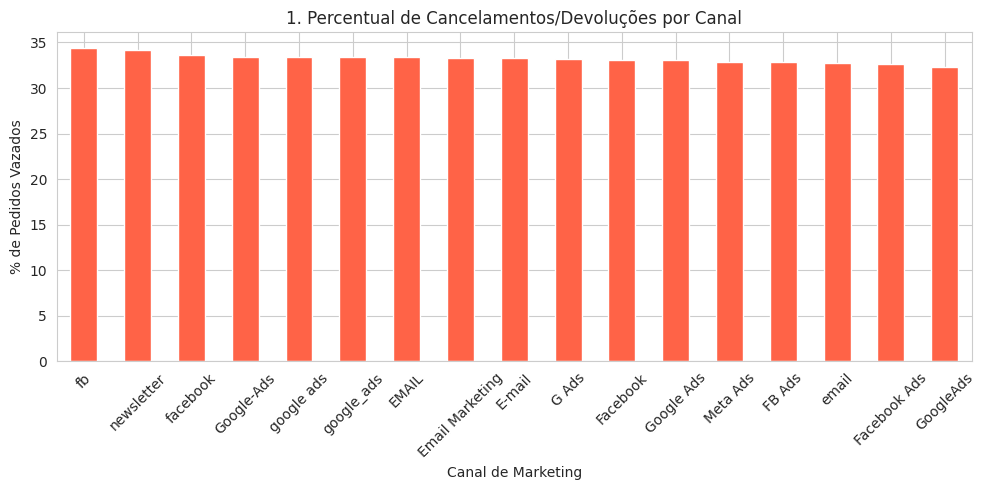

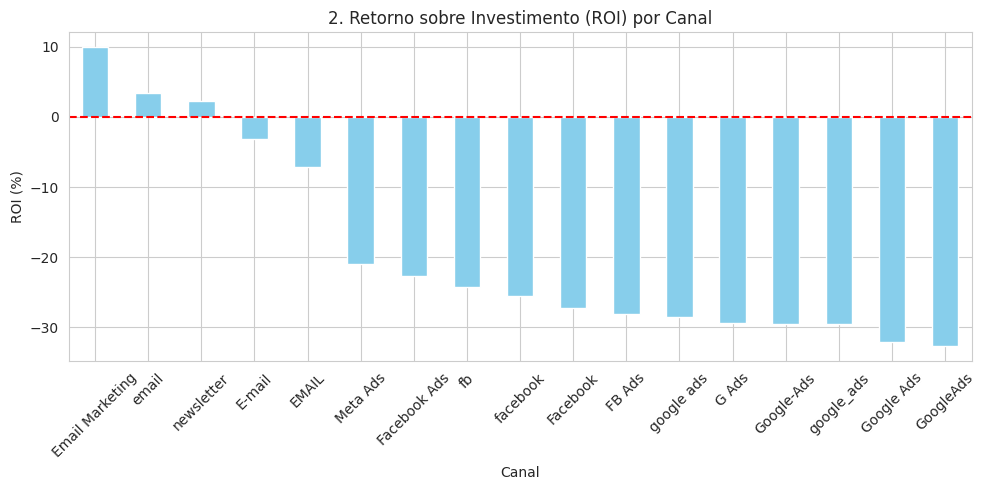

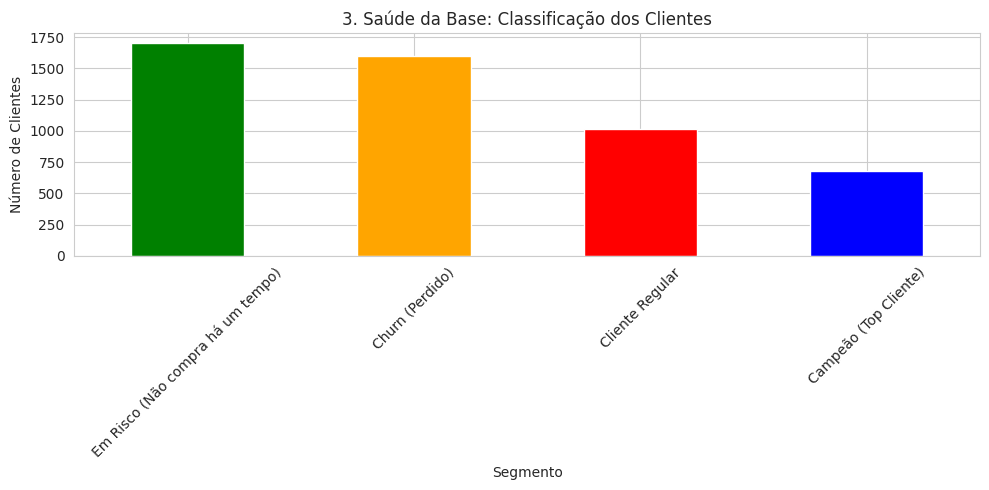


Todos os gráficos foram salvos na pasta 'report'.


In [6]:
# Gráfico 1: Cancelamentos por Canal
leakage = df_final[df_final['is_cancelled'] == True].groupby('attributed_channel').size()
total_por_canal = df_final.groupby('attributed_channel').size()
pct_leakage = (leakage / total_por_canal * 100).sort_values(ascending=False)

plt.figure()
pct_leakage.plot(kind='bar', color='tomato')
plt.title('1. Percentual de Cancelamentos/Devoluções por Canal')
plt.ylabel('% de Pedidos Vazados')
plt.xlabel('Canal de Marketing')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../report/grafico1_leakage.png')
plt.show()

# Gráfico 2: ROI por Canal
performance = df_final.groupby('attributed_channel').agg({
    'net_revenue': 'sum',
    'daily_investment': 'sum'
})
performance['ROI'] = ((performance['net_revenue'] - performance['daily_investment']) / performance['daily_investment']) * 100
performance['ROI'] = performance['ROI'].fillna(0)

plt.figure()
performance['ROI'].sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('2. Retorno sobre Investimento (ROI) por Canal')
plt.ylabel('ROI (%)')
plt.xlabel('Canal')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../report/grafico2_roi.png')
plt.show()

# Gráfico 3: Segmentação de Clientes
plt.figure()
rfm['Segmento'].value_counts().plot(kind='bar', color=['green', 'orange', 'red', 'blue'])
plt.title('3. Saúde da Base: Classificação dos Clientes')
plt.ylabel('Número de Clientes')
plt.xlabel('Segmento')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../report/grafico3_segmentos.png')
plt.show()

print("\nTodos os gráficos foram salvos na pasta 'report'.")